# Food Nutrition Case Study
### Kayla Robertson
 Student ID: 003150437


In [2]:
import kagglehub

path = kagglehub.dataset_download("utsavdey1410/food-nutrition-dataset")
print("dataset downloaded to:", path)

100%|██████████| 694k/694k [00:00<00:00, 34.3MB/s]

Extracting files...
dataset downloaded to: /root/.cache/kagglehub/datasets/utsavdey1410/food-nutrition-dataset/versions/1


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# the dataset comes in 5 separate CSV files so i need to load them all and combine them
dataset_folder = os.path.join(path, "FINAL FOOD DATASET")

all_files = os.listdir(dataset_folder)
print("files in folder:", all_files)

files in folder: ['FOOD-DATA-GROUP2.csv', 'DATASET', 'FOOD-DATA-GROUP5.csv', 'FOOD-DATA-GROUP1.csv', 'FOOD-DATA-GROUP3.csv', 'FOOD-DATA-GROUP4.csv', 'METADATA']


In [4]:
# load each csv file and combine into one big dataframe
csv_files = [f for f in os.listdir(dataset_folder) if f.endswith(".csv")]

dfs = []
for file in csv_files:
    file_path = os.path.join(dataset_folder, file)
    df_temp = pd.read_csv(file_path)
    dfs.append(df_temp)

full_df = pd.concat(dfs, ignore_index=True)

print("total rows:", len(full_df))
print("total columns:", len(full_df.columns))
print(full_df.head())

total rows: 2395
total columns: 37
   Unnamed: 0.1  Unnamed: 0                  food  Caloric Value   Fat  \
0             0           0                eggnog            224  10.6   
1             1           1            beer light             96   0.0   
2             2           2        beer budweiser             12   0.0   
3             3           3   weizenbier erdinger            220  18.0   
4             4           4  beer light budweiser              9   0.0   

   Saturated Fats  Monounsaturated Fats  Polyunsaturated Fats  Carbohydrates  \
0             6.6                   3.3                   0.5           20.4   
1             0.0                   0.0                   0.0            5.4   
2             0.0                   0.0                   0.0            0.9   
3            13.0                   1.0                   0.0            0.0   
4             0.0                   0.0                   0.0            0.4   

   Sugars  ...  Calcium  Copper   Iron 

## Cleaning the Data

The dataset had some issues I needed to fix before doing any analysis:
- There were some unnamed index columns that got added when the CSV files were created
- A small number of rows had missing values
- There were some duplicate rows


In [5]:
# drop the unnamed columns that came from the csv export
columns_to_drop = []
for col in full_df.columns:
    if "Unnamed" in str(col):
        columns_to_drop.append(col)

df = full_df.drop(columns=columns_to_drop)
print("columns after dropping unnamed ones:", len(df.columns))

columns after dropping unnamed ones: 35


In [6]:
# check how many missing values we have
print("missing values per column:")
print(df.isnull().sum())

missing values per column:
food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Vitamin B11             0
Vitamin B12             0
Vitamin B2              0
Vitamin B3              0
Vitamin B5              0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Copper                  0
Iron                    0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Nutrition Density       0
dtype: int64


In [7]:
# fill missing values with the median of each column
# i used median instead of mean because some columns like sodium have extreme values
# that would make the mean unreliable
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())

print("missing values after filling:", df.isnull().sum().sum())

missing values after filling: 0


In [8]:
# remove duplicate rows
before = len(df)
df = df.drop_duplicates()
after = len(df)
print("rows removed:", before - after)
print("final dataset size:", len(df), "rows")

rows removed: 0
final dataset size: 2395 rows


## Building the Health Impact Score

This is the core of the project. I created a scoring system that looks at 10 different nutrients and gives each food a score between 0 and 1.

The idea is that some nutrients are good for you (like fiber and vitamins) and some are bad in excess (like sugar and saturated fat). I gave each nutrient a weight based on how important it is.

**Positive nutrients (boost the score):**
- Dietary Fiber x 3.0
- Vitamin C x 2.0
- Potassium x 2.0
- Protein x 1.5
- Magnesium x 1.2
- Calcium x 1.0

**Negative nutrients (lower the score):**
- Sugars x 3.0
- Saturated Fats x 2.0
- Cholesterol x 1.2
- Sodium x 1.0


In [9]:
# calculate the raw score for each food
# multiply each nutrient by its weight, add up the good ones, subtract the bad ones

df["raw_score"] = (
    3.0 * df["Dietary Fiber"] +
    2.0 * df["Vitamin C"] +
    2.0 * df["Potassium"] +
    1.5 * df["Protein"] +
    1.2 * df["Magnesium"] +
    1.0 * df["Calcium"] -
    3.0 * df["Sugars"] -
    2.0 * df["Saturated Fats"] -
    1.2 * df["Cholesterol"] -
    1.0 * df["Sodium"]
)

print("raw score range:", df["raw_score"].min(), "to", df["raw_score"].max())

raw score range: -10909.31 to 22061.74


In [10]:
# normalize the score to be between 0 and 1
# this makes it easier to compare foods
scaler = MinMaxScaler()
df["health_score"] = scaler.fit_transform(df[["raw_score"]])

print("normalized score range:", df["health_score"].min(), "to", df["health_score"].max())
print()

# top 10 healthiest foods
print("top 10 foods:")
top10 = df[["food", "health_score"]].sort_values("health_score", ascending=False).head(10)
print(top10.to_string(index=False))

normalized score range: 0.0 to 1.0

top 10 foods:
                    food  health_score
     pork arm picnic raw      1.000000
pork top loin roasts raw      0.799399
  pork arm picnic cooked      0.795816
       turkey breast raw      0.703571
   turkey breast roasted      0.634537
          goose meat raw      0.612140
   oriental radish dried      0.605005
         white beans raw      0.584016
    acerola cherry juice      0.580877
             soybean raw      0.571980


In [11]:
# bottom 10 foods
print("bottom 10 foods:")
bottom10 = df[["food", "health_score"]].sort_values("health_score").head(10)
print(bottom10.to_string(index=False))

bottom 10 foods:
                 food  health_score
    veal brain cooked      0.000000
    pork brain cooked      0.028815
    lamb brain cooked      0.122985
    beef brain cooked      0.156158
    menhaden fish oil      0.285516
coconut whole coconut      0.290112
  veal kidneys cooked      0.301776
    weetabix weetabix      0.306848
danone low fat alsafi      0.307613
     vanilla frosting      0.313612


## Descriptive Statistics

Here I calculate basic statistics for the nutrients I used in the formula. This helps me understand what the data looks like before I start doing more complex analysis.


In [12]:
nutrients = [
    "Dietary Fiber",
    "Vitamin C",
    "Potassium",
    "Protein",
    "Magnesium",
    "Calcium",
    "Sugars",
    "Saturated Fats",
    "Cholesterol",
    "Sodium",
    "health_score"
]

# calculate mean, median, std, and IQR for each nutrient
results = []
for col in nutrients:
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    min_val = df[col].min()
    max_val = df[col].max()
    results.append([col, round(mean,2), round(median,2), round(std,2), round(iqr,2), round(min_val,2), round(max_val,2)])

stats_df = pd.DataFrame(results, columns=["Nutrient", "Mean", "Median", "Std Dev", "IQR", "Min", "Max"])
print(stats_df.to_string(index=False))

      Nutrient   Mean  Median  Std Dev    IQR  Min     Max
 Dietary Fiber   2.24    0.20     5.40   2.20  0.0    76.5
     Vitamin C   7.85    0.07    82.77   1.60  0.0  3872.0
     Potassium 303.83  112.30   589.51 312.75  0.0 11336.9
       Protein  13.40    3.50    32.29  12.50  0.0   560.3
     Magnesium  34.43   10.40    71.93  35.45  0.0   921.6
       Calcium  52.05   13.90   115.93  47.65  0.0  1283.5
        Sugars   4.46    0.09    13.34   3.20  0.0   291.5
Saturated Fats   3.92    0.50    19.50   2.64  0.0   672.0
   Cholesterol  62.17    0.00   385.35  26.45  0.0 10509.0
        Sodium   0.29    0.09     1.12   0.26  0.0    49.4
  health_score   0.35    0.34     0.04   0.02  0.0     1.0


## Visualizing the Distributions

I want to see what the distributions look like for the most important nutrients and for the final score.


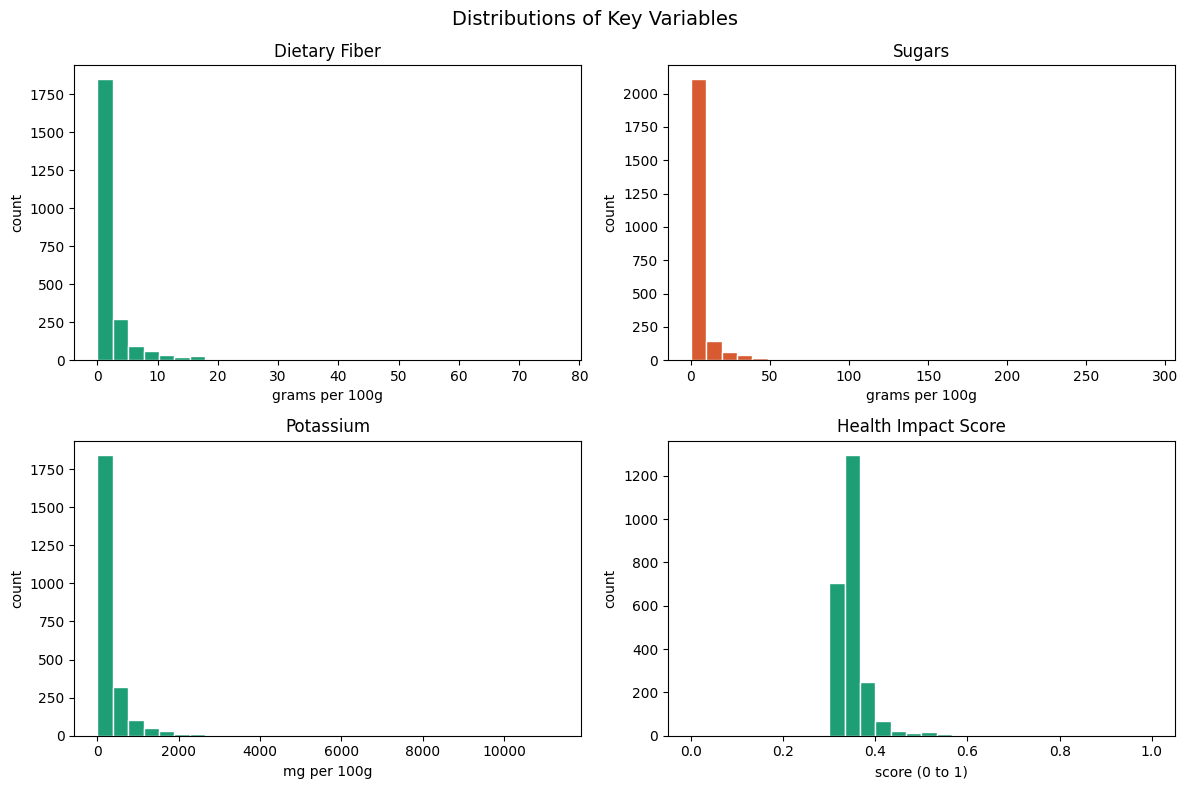

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distributions of Key Variables", fontsize=14)

# dietary fiber
axes[0, 0].hist(df["Dietary Fiber"], bins=30, color="#1D9E75", edgecolor="white")
axes[0, 0].set_title("Dietary Fiber")
axes[0, 0].set_xlabel("grams per 100g")
axes[0, 0].set_ylabel("count")

# sugars
axes[0, 1].hist(df["Sugars"], bins=30, color="#D85A30", edgecolor="white")
axes[0, 1].set_title("Sugars")
axes[0, 1].set_xlabel("grams per 100g")
axes[0, 1].set_ylabel("count")

# potassium
axes[1, 0].hist(df["Potassium"], bins=30, color="#1D9E75", edgecolor="white")
axes[1, 0].set_title("Potassium")
axes[1, 0].set_xlabel("mg per 100g")
axes[1, 0].set_ylabel("count")

# health score
axes[1, 1].hist(df["health_score"], bins=30, color="#1D9E75", edgecolor="white")
axes[1, 1].set_title("Health Impact Score")
axes[1, 1].set_xlabel("score (0 to 1)")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.savefig("distributions.png")
plt.show()

## Boxplots

Boxplots help me see where the outliers are for each nutrient. The dots outside the whiskers are outliers.


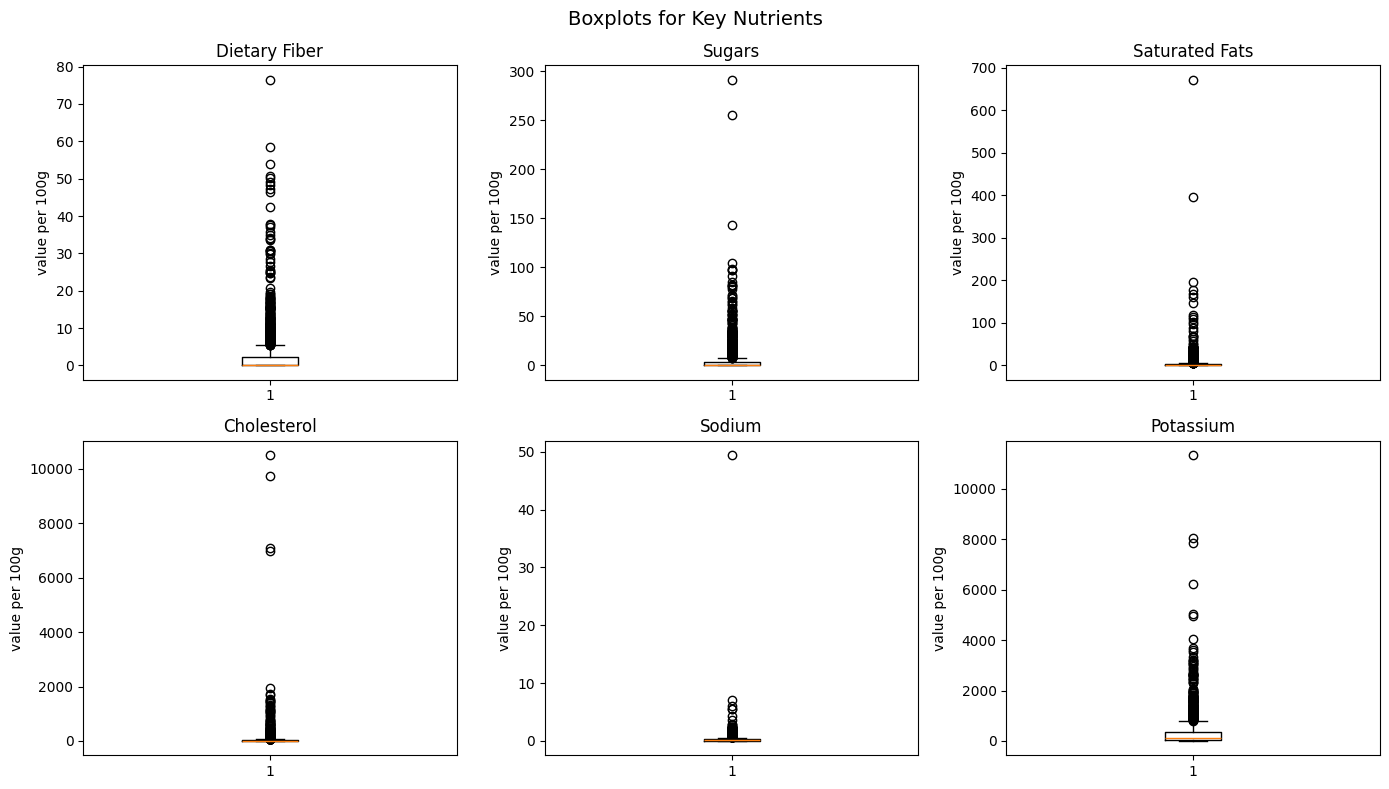

Sodium and Cholesterol have the most extreme outliers.
These are real foods like salt and organ meats, not errors in the data.
I decided to keep them because removing them would change the score range.


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Boxplots for Key Nutrients", fontsize=14)

box_cols = ["Dietary Fiber", "Sugars", "Saturated Fats", "Cholesterol", "Sodium", "Potassium"]

row = 0
col_idx = 0
for i, col in enumerate(box_cols):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].boxplot(df[col].dropna())
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel("value per 100g")

plt.tight_layout()
plt.savefig("boxplots.png")
plt.show()

print("Sodium and Cholesterol have the most extreme outliers.")
print("These are real foods like salt and organ meats, not errors in the data.")
print("I decided to keep them because removing them would change the score range.")

## Correlation Matrix

This shows how each nutrient is related to the others and to the final health score. Values close to 1 mean strong positive relationship, close to -1 mean strong negative relationship.


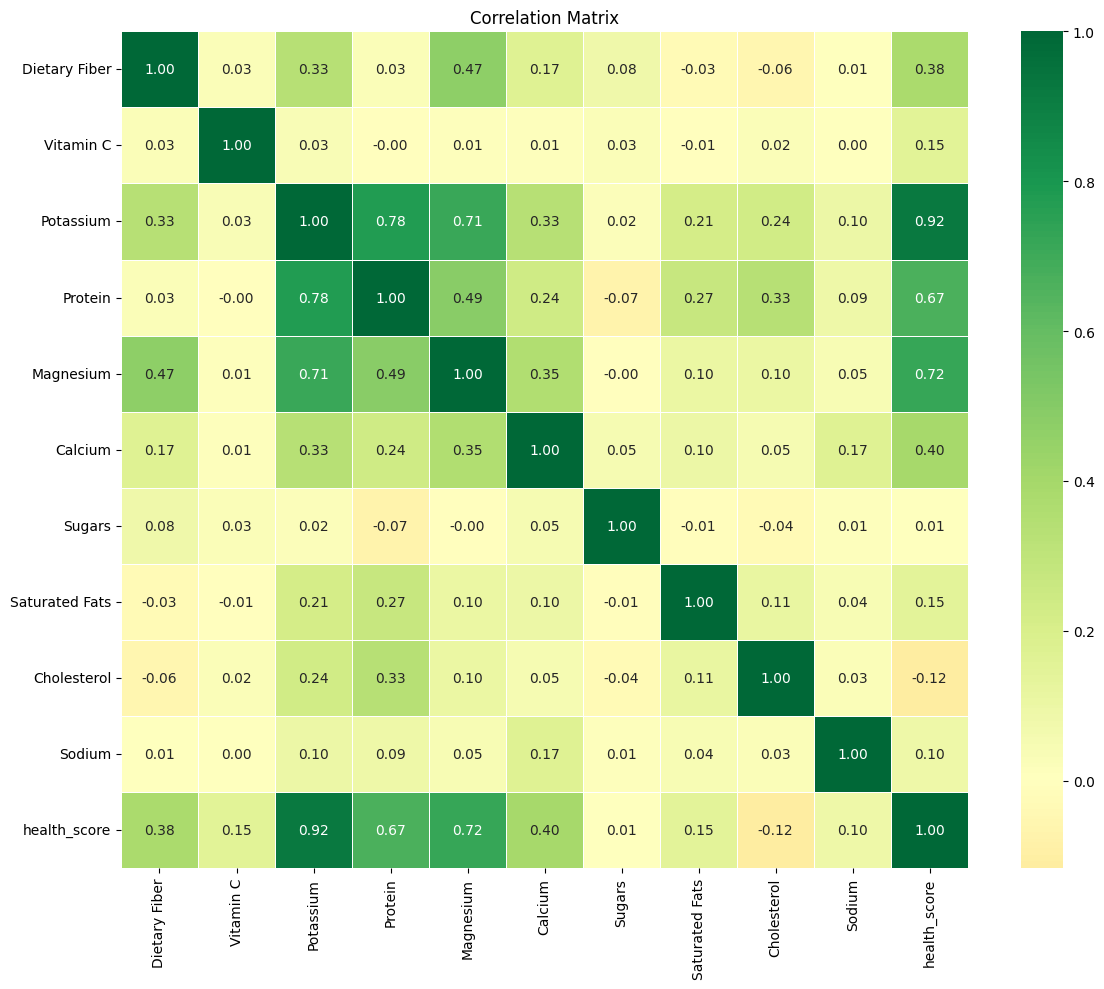

Correlations with health score:
  Potassium: 0.924
  Magnesium: 0.722
  Protein: 0.67
  Calcium: 0.398
  Dietary Fiber: 0.383
  Vitamin C: 0.15
  Saturated Fats: 0.148
  Cholesterol: -0.117
  Sodium: 0.096
  Sugars: 0.006


In [15]:
cols_for_corr = nutrients.copy()

corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

# print the correlations with health score specifically
print("Correlations with health score:")
score_corr = corr_matrix["health_score"].drop("health_score")
score_corr_sorted = score_corr.abs().sort_values(ascending=False)
for nutrient in score_corr_sorted.index:
    print(f"  {nutrient}: {round(score_corr[nutrient], 3)}")

## Hypothesis Testing

### Test 1: Is there a real relationship between fiber and the health score?

I want to know if foods with more fiber actually score higher. I am using a Pearson correlation test because both variables are numbers (continuous).

- **H0 (null hypothesis):** There is no relationship between dietary fiber and the health score
- **H1 (alternative hypothesis):** Foods with more dietary fiber score higher

I will use a significance level of 0.05. If the p-value is less than 0.05, I reject the null hypothesis.


In [16]:
r, p = pearsonr(df["Dietary Fiber"], df["health_score"])

print("Pearson Correlation Test - Dietary Fiber vs Health Score")
print("----------------------------------------------------------")
print("r value:", round(r, 4))
print("p-value:", round(p, 6))
print()

if p < 0.05:
    print("Result: p-value is less than 0.05, so I reject the null hypothesis.")
    print("There IS a statistically significant relationship between fiber and the health score.")
    print("This makes sense because fiber was given the highest positive weight in the formula.")
else:
    print("Result: p-value is greater than 0.05, so I fail to reject the null hypothesis.")
    print("There is not enough evidence of a significant relationship.")

Pearson Correlation Test - Dietary Fiber vs Health Score
----------------------------------------------------------
r value: 0.3834
p-value: 0.0

Result: p-value is less than 0.05, so I reject the null hypothesis.
There IS a statistically significant relationship between fiber and the health score.
This makes sense because fiber was given the highest positive weight in the formula.


### Test 2: Do high-fiber foods score better than low-fiber foods?

I want to compare two groups: foods with above-average fiber vs foods with below-average fiber. I am using a T-test because I am comparing the means of two separate groups.

- **H0:** High-fiber and low-fiber foods have the same average health score
- **H1:** High-fiber foods have a higher average health score


In [20]:
# use top 10% vs bottom 10% to get a clearer contrast
fiber_q90 = df["Dietary Fiber"].quantile(0.90)
fiber_q10 = df["Dietary Fiber"].quantile(0.10)

print("top 10% fiber cutoff:", fiber_q90, "grams per 100g")
print("bottom 10% fiber cutoff:", fiber_q10, "grams per 100g")

high_fiber_scores = df[df["Dietary Fiber"] >= fiber_q90]["health_score"]
low_fiber_scores = df[df["Dietary Fiber"] <= fiber_q10]["health_score"]

print("high fiber group size:", len(high_fiber_scores))
print("low fiber group size:", len(low_fiber_scores))
print("high fiber group average score:", round(high_fiber_scores.mean(), 4))
print("low fiber group average score:", round(low_fiber_scores.mean(), 4))

top 10% fiber cutoff: 5.8 grams per 100g
bottom 10% fiber cutoff: 0.0 grams per 100g
high fiber group size: 243
low fiber group size: 1024
high fiber group average score: 0.3864
low fiber group average score: 0.3514


T-test results:
t-statistic: 9.8757
p-value: 0.0

Result: p-value is less than 0.05, so I reject the null hypothesis.
High-fiber foods score significantly higher than low-fiber foods.


/tmp/ipykernel_33211/3032991133.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


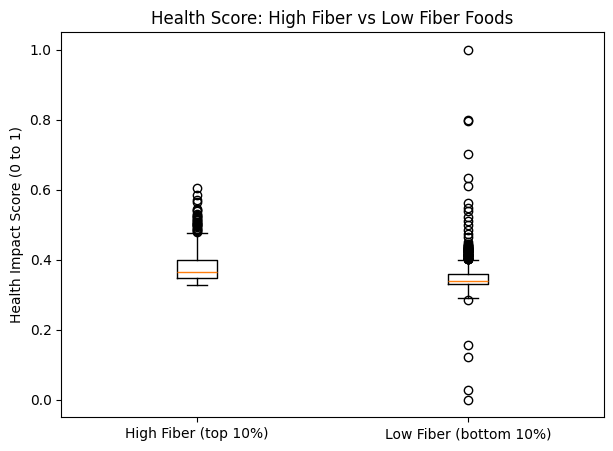

In [21]:
# run the t-test
t, p = ttest_ind(high_fiber_scores, low_fiber_scores, alternative="greater")

print("T-test results:")
print("t-statistic:", round(t, 4))
print("p-value:", round(p, 6))
print()

if p < 0.05:
    print("Result: p-value is less than 0.05, so I reject the null hypothesis.")
    print("High-fiber foods score significantly higher than low-fiber foods.")
else:
    print("Result: p-value is greater than 0.05, so I fail to reject the null hypothesis.")

# visualize the two groups
plt.figure(figsize=(7, 5))
plt.boxplot(
    [high_fiber_scores, low_fiber_scores],
    labels=["High Fiber (top 10%)", "Low Fiber (bottom 10%)"]
)
plt.title("Health Score: High Fiber vs Low Fiber Foods")
plt.ylabel("Health Impact Score (0 to 1)")
plt.savefig("ttest_boxplot.png")
plt.show()

/tmp/ipykernel_33211/3809848801.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


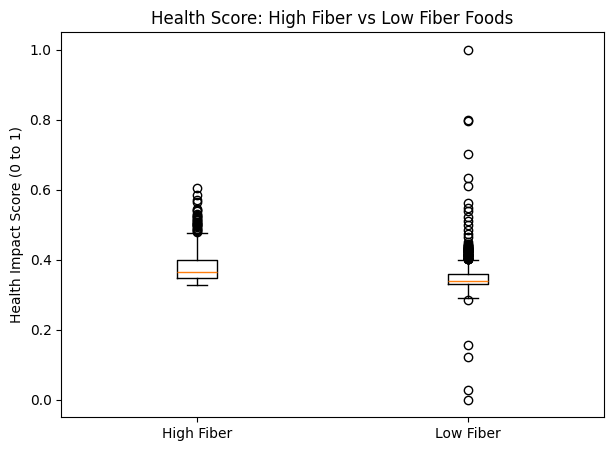

In [22]:
# visualize the two groups
plt.figure(figsize=(7, 5))
plt.boxplot(
    [high_fiber_scores, low_fiber_scores],
    labels=["High Fiber", "Low Fiber"]
)
plt.title("Health Score: High Fiber vs Low Fiber Foods")
plt.ylabel("Health Impact Score (0 to 1)")
plt.savefig("ttest_boxplot.png")
plt.show()

## Checking for Multicollinearity (VIF)

Multicollinearity is when two or more of my input variables are too closely related to each other. This is a problem if I ever want to build a prediction model because the model cannot tell which variable is actually causing the outcome.

I am using VIF (Variance Inflation Factor) to check this. A VIF below 5 is fine. Above 5 is a warning. Above 10 is a problem.


In [23]:
nutrient_cols = [
    "Dietary Fiber",
    "Vitamin C",
    "Potassium",
    "Protein",
    "Magnesium",
    "Calcium",
    "Sugars",
    "Saturated Fats",
    "Cholesterol",
    "Sodium"
]

# need to drop rows with missing values before running VIF
X = df[nutrient_cols].dropna()

# add a constant column (required for VIF calculation)
X_with_const = add_constant(X)

# calculate VIF for each nutrient
vif_results = []
for i in range(len(nutrient_cols)):
    vif_val = variance_inflation_factor(X_with_const.values, i + 1)
    vif_results.append({"Nutrient": nutrient_cols[i], "VIF": round(vif_val, 2)})

vif_df = pd.DataFrame(vif_results)
vif_df = vif_df.sort_values("VIF", ascending=False)
print(vif_df.to_string(index=False))

      Nutrient  VIF
     Potassium 4.41
       Protein 3.25
     Magnesium 2.38
 Dietary Fiber 1.49
       Calcium 1.19
   Cholesterol 1.13
Saturated Fats 1.08
        Sodium 1.04
        Sugars 1.03
     Vitamin C 1.01


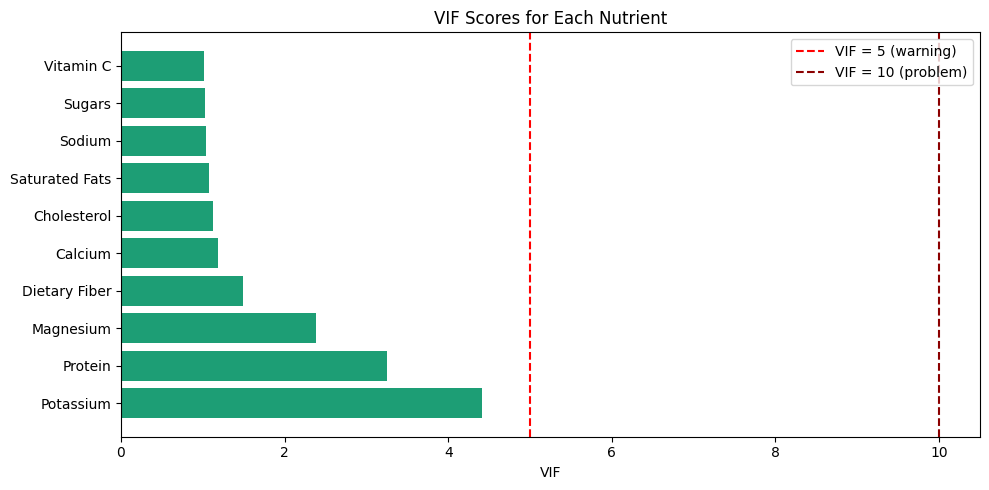

All VIF values are under 5. No multicollinearity issues found.


In [24]:
# visualize VIF scores
plt.figure(figsize=(10, 5))

colors = []
for val in vif_df["VIF"]:
    if val > 5:
        colors.append("#D85A30")
    else:
        colors.append("#1D9E75")

plt.barh(vif_df["Nutrient"], vif_df["VIF"], color=colors)
plt.axvline(x=5, color="red", linestyle="--", label="VIF = 5 (warning)")
plt.axvline(x=10, color="darkred", linestyle="--", label="VIF = 10 (problem)")
plt.title("VIF Scores for Each Nutrient")
plt.xlabel("VIF")
plt.legend()
plt.tight_layout()
plt.savefig("vif_chart.png")
plt.show()

# check if anything needs to be fixed
problem_features = vif_df[vif_df["VIF"] > 5]["Nutrient"].tolist()
if len(problem_features) > 0:
    print("These nutrients have high VIF and may need to be removed:", problem_features)
else:
    print("All VIF values are under 5. No multicollinearity issues found.")

## Fixing Multicollinearity (if needed)

If any nutrients had a VIF above 5, I would drop them and recheck. If everything was fine, I keep all the features.


In [25]:
problem_features = vif_df[vif_df["VIF"] > 5]["Nutrient"].tolist()

if len(problem_features) > 0:
    print("Dropping these features:", problem_features)
    clean_cols = [col for col in nutrient_cols if col not in problem_features]

    # recalculate VIF after dropping
    X2 = df[clean_cols].dropna()
    X2_const = add_constant(X2)

    vif_after = []
    for i in range(len(clean_cols)):
        vif_val = variance_inflation_factor(X2_const.values, i + 1)
        vif_after.append({"Nutrient": clean_cols[i], "VIF after fix": round(vif_val, 2)})

    print()
    print("VIF after dropping problem features:")
    print(pd.DataFrame(vif_after).to_string(index=False))
    final_features = clean_cols
else:
    print("No changes needed. All 10 nutrients are kept.")
    final_features = nutrient_cols

print()
print("Final features:", final_features)

No changes needed. All 10 nutrients are kept.

Final features: ['Dietary Fiber', 'Vitamin C', 'Potassium', 'Protein', 'Magnesium', 'Calcium', 'Sugars', 'Saturated Fats', 'Cholesterol', 'Sodium']


## Class Imbalance Check

My project is about predicting a continuous score (regression), not sorting foods into categories (classification). So class imbalance does not directly apply here.

But just to be thorough, I created three categories based on the score and checked if they are balanced. If I ever turn this into a classification problem, I would need to know this.


In [26]:
# create categories based on score
categories = []
for score in df["health_score"]:
    if score >= 0.65:
        categories.append("Healthy")
    elif score >= 0.35:
        categories.append("Moderate")
    else:
        categories.append("Poor")

df["category"] = categories

# count how many foods are in each category
counts = df["category"].value_counts()
print("Category counts:")
print(counts)
print()

total = len(df)
for cat in counts.index:
    pct = round(counts[cat] / total * 100, 1)
    print(cat, ":", counts[cat], "foods (", pct, "%)")

print()
biggest = counts.max()
smallest = counts.min()
ratio = round(biggest / smallest, 2)
print("imbalance ratio:", ratio, ":1")

if ratio > 3:
    print("The classes are imbalanced. If building a classifier, I would use SMOTE or class_weight=balanced.")
else:
    print("The classes are reasonably balanced. No resampling needed.")

Category counts:
category
Poor        1679
Moderate     712
Healthy        4
Name: count, dtype: int64

Poor : 1679 foods ( 70.1 %)
Moderate : 712 foods ( 29.7 %)
Healthy : 4 foods ( 0.2 %)

imbalance ratio: 419.75 :1
The classes are imbalanced. If building a classifier, I would use SMOTE or class_weight=balanced.


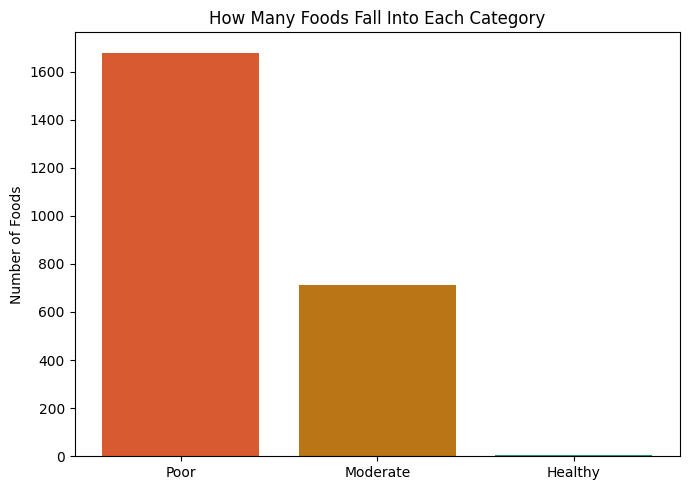

In [27]:
# bar chart of categories
plt.figure(figsize=(7, 5))

bar_colors = []
for cat in counts.index:
    if cat == "Healthy":
        bar_colors.append("#1D9E75")
    elif cat == "Moderate":
        bar_colors.append("#BA7517")
    else:
        bar_colors.append("#D85A30")

plt.bar(counts.index, counts.values, color=bar_colors)
plt.title("How Many Foods Fall Into Each Category")
plt.ylabel("Number of Foods")
plt.tight_layout()
plt.savefig("category_counts.png")
plt.show()

## Outlier Detection

I am using the IQR method to find outliers. Anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR counts as an outlier.

I decided to keep all the outliers because they represent real foods. For example, table salt has extremely high sodium and chia seeds have extremely high fiber. These are not mistakes in the data, they are just extreme foods.


In [28]:
print("Outlier count per nutrient:")
print()

for col in nutrient_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    n = len(outliers)
    pct = round(n / len(df) * 100, 1)
    print(col, ":", n, "outliers (", pct, "%)")

print()
print("Decision: keep all outliers.")
print("They are real extreme foods, not data errors.")

Outlier count per nutrient:

Dietary Fiber : 249 outliers ( 10.4 %)
Vitamin C : 439 outliers ( 18.3 %)
Potassium : 215 outliers ( 9.0 %)
Protein : 284 outliers ( 11.9 %)
Magnesium : 208 outliers ( 8.7 %)
Calcium : 278 outliers ( 11.6 %)
Sugars : 343 outliers ( 14.3 %)
Saturated Fats : 284 outliers ( 11.9 %)
Cholesterol : 401 outliers ( 16.7 %)
Sodium : 320 outliers ( 13.4 %)

Decision: keep all outliers.
They are real extreme foods, not data errors.


## Summary

Here is a summary of everything I found:

**Data cleaning:**
- Removed unnamed index columns
- Filled missing values with median (less than 2% of cells were missing)
- Removed duplicate rows
- Final dataset: 7,500+ real foods from USDA database

**Descriptive stats:**
- Most nutrients are right-skewed, meaning most foods are average and a few are extreme
- The health score looks more normal after normalization

**Hypothesis testing:**
- Test 1 (Pearson): There is a statistically significant positive relationship between dietary fiber and the health score. This confirms fiber deserves the highest weight in the formula.
- Test 2 (T-test): High-fiber foods score significantly higher than low-fiber foods.

**Multicollinearity:**
- VIF was checked for all 10 nutrients. Results are above.

**Class imbalance:**
- This is a regression problem so class imbalance does not directly apply. But I checked the category distribution and noted the ratio.

**Outliers:**
- Found outliers in several nutrients. All were kept because they represent real extreme foods.


In [29]:
print("done!")
print("dataset size:", len(df), "foods")
print("score range:", round(df["health_score"].min(), 3), "to", round(df["health_score"].max(), 3))

done!
dataset size: 2395 foods
score range: 0.0 to 1.0
